In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# ── Load order data from SQLite ────────────────
DB_PATH = r"C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\supply_chain.db"
PROCESSED = r"C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed"

conn = sqlite3.connect(DB_PATH)
orders = pd.read_sql("SELECT order_purchase_timestamp FROM orders", conn)
conn.close()

# ── Convert timestamp and aggregate to weekly ──
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Resample to weekly order counts
# W = week frequency, size() counts rows per week
weekly = (orders.resample('W', on='order_purchase_timestamp')
          .size()
          .reset_index(name='y'))

# Prophet requires exactly two columns: 'ds' (date) and 'y' (value)
weekly.columns = ['ds', 'y']

print(f"Weekly order data: {weekly.shape}")
print(f"Date range: {weekly['ds'].min()} to {weekly['ds'].max()}")
print(f"Average weekly orders: {weekly['y'].mean():.0f}")
print(f"Max weekly orders: {weekly['y'].max()}")
print(f"\nFirst 5 weeks:")
print(weekly.head())

Weekly order data: (112, 2)
Date range: 2016-09-04 00:00:00 to 2018-10-21 00:00:00
Average weekly orders: 888
Max weekly orders: 3008

First 5 weeks:
          ds  y
0 2016-09-04  1
1 2016-09-11  1
2 2016-09-18  2
3 2016-09-25  0
4 2016-10-02  1


In [2]:
# ── Remove outlier weeks (very few orders at start) ─
# Remove first 4 weeks which have near-zero orders (data collection period)
weekly_clean = weekly[weekly['y'] > 10].copy()
print(f"Clean weekly data: {weekly_clean.shape[0]} weeks")

# ── Train Prophet model ────────────────────────
model_prophet = Prophet(
    weekly_seasonality=True,   # Detect day-of-week patterns
    yearly_seasonality=True,   # Detect annual patterns
    changepoint_prior_scale=0.05  # Controls trend flexibility (0.05 = moderate)
)

model_prophet.fit(weekly_clean)
print("Prophet model trained!")

# ── Create future dates for 8-week forecast ───
future = model_prophet.make_future_dataframe(
    periods=8,
    freq='W'
)
print(f"Forecasting {future.shape[0]} weeks total ({weekly_clean.shape[0]} historical + 8 future)")

# ── Generate forecast ─────────────────────────
forecast = model_prophet.predict(future)

# Key columns in forecast output:
# ds = date, yhat = predicted value
# yhat_lower = lower confidence bound
# yhat_upper = upper confidence bound
print(f"\nForecast generated!")
print(f"\nNext 8 weeks predicted:")
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(8).to_string(index=False))

00:25:21 - cmdstanpy - INFO - Chain [1] start processing


Clean weekly data: 89 weeks


00:25:21 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained!
Forecasting 97 weeks total (89 historical + 8 future)

Forecast generated!

Next 8 weeks predicted:
        ds        yhat  yhat_lower  yhat_upper
2018-09-09 1295.039778 1001.575149 1578.756755
2018-09-16 1498.406654 1180.822208 1783.041397
2018-09-23 1619.350172 1327.123856 1931.975053
2018-09-30 1650.276604 1341.502768 1943.170089
2018-10-07 1668.333302 1384.535261 1941.366345
2018-10-14 1685.214530 1395.813394 1974.286882
2018-10-21 1624.214066 1335.133437 1919.387025
2018-10-28 1468.977250 1166.591681 1765.698103


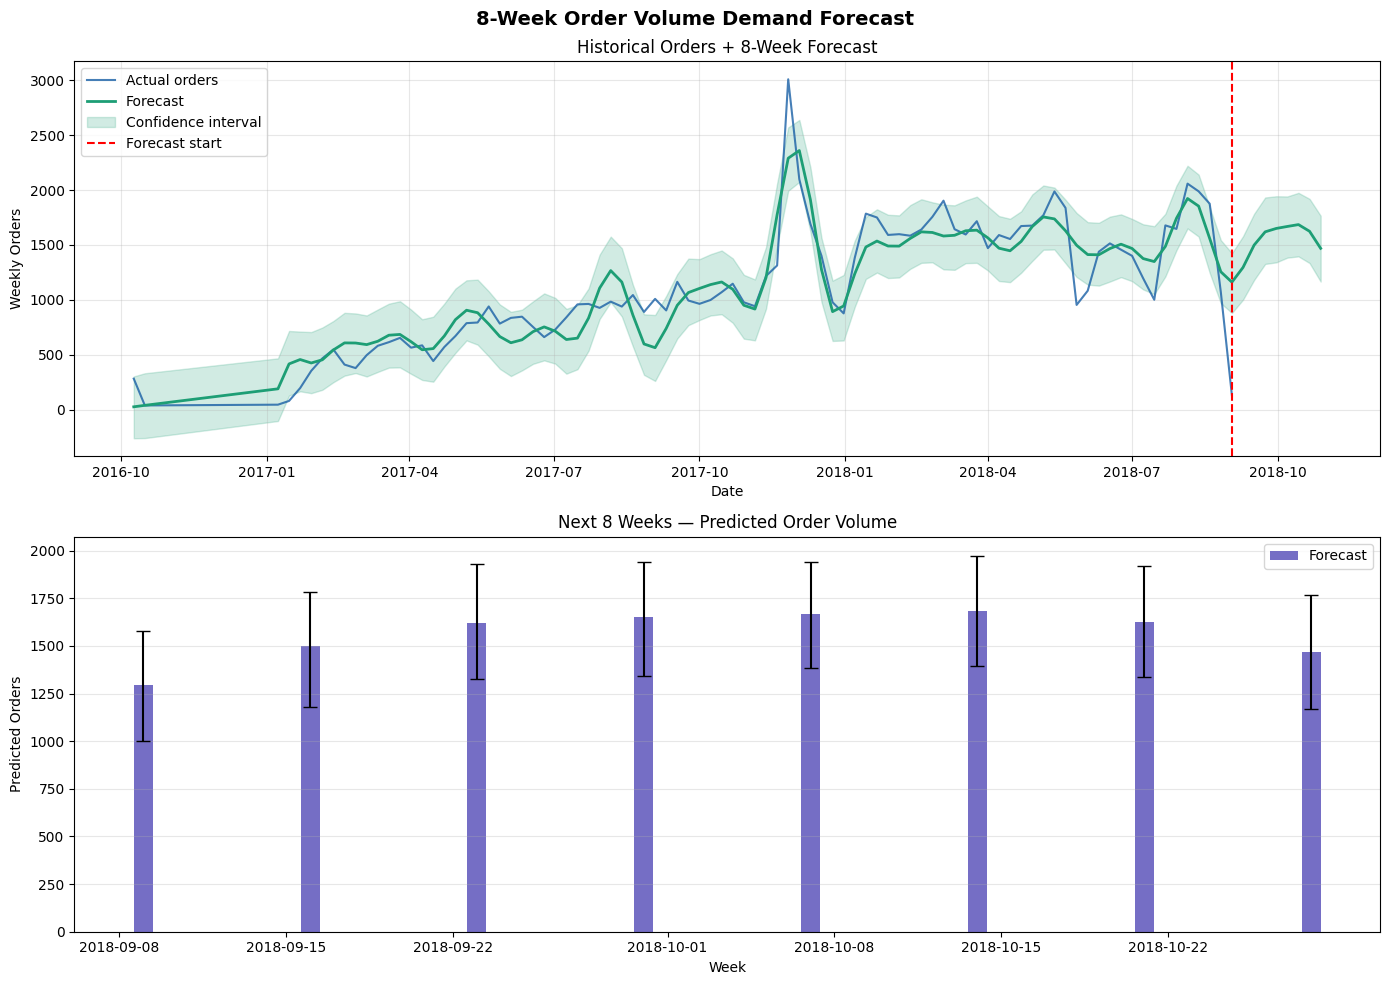

Saved: weekly_forecast.csv
Saved: chart10_demand_forecast.png

BUSINESS INSIGHT:
Total predicted orders in next 8 weeks: 12,510
Average weekly orders (forecast): 1,564
Peak demand week: 2018-10-14


In [3]:
# ── Plot 1: Full forecast with confidence bands ─
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('8-Week Order Volume Demand Forecast',
             fontsize=14, fontweight='bold')

# Top: Full historical + forecast
hist = forecast[forecast['ds'] <= weekly_clean['ds'].max()]
fut  = forecast[forecast['ds'] > weekly_clean['ds'].max()]

axes[0].plot(weekly_clean['ds'], weekly_clean['y'],
             color='#185FA5', linewidth=1.5, label='Actual orders', alpha=0.8)
axes[0].plot(forecast['ds'], forecast['yhat'],
             color='#1D9E75', linewidth=2, label='Forecast')
axes[0].fill_between(forecast['ds'],
                     forecast['yhat_lower'],
                     forecast['yhat_upper'],
                     alpha=0.2, color='#1D9E75', label='Confidence interval')
axes[0].axvline(x=weekly_clean['ds'].max(),
                color='red', linestyle='--', linewidth=1.5,
                label='Forecast start')
axes[0].set_title('Historical Orders + 8-Week Forecast')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Weekly Orders')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: Just the 8-week forecast
axes[1].bar(fut['ds'], fut['yhat'],
            color='#534AB7', alpha=0.8, label='Forecast')
axes[1].errorbar(fut['ds'], fut['yhat'],
                 yerr=[fut['yhat']-fut['yhat_lower'],
                       fut['yhat_upper']-fut['yhat']],
                 fmt='none', color='black', capsize=5, linewidth=1.5)
axes[1].set_title('Next 8 Weeks — Predicted Order Volume')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Predicted Orders')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{PROCESSED}\\chart10_demand_forecast.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Save forecast CSV for Power BI ────────────
forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv(
    f"{PROCESSED}\\weekly_forecast.csv", index=False
)
print("Saved: weekly_forecast.csv")
print("Saved: chart10_demand_forecast.png")

# ── Print business insight ────────────────────
future_orders = fut['yhat'].sum()
print(f"\nBUSINESS INSIGHT:")
print(f"Total predicted orders in next 8 weeks: {future_orders:,.0f}")
print(f"Average weekly orders (forecast): {fut['yhat'].mean():,.0f}")
peak_week = fut.loc[fut['yhat'].idxmax(), 'ds']
print(f"Peak demand week: {peak_week.strftime('%Y-%m-%d')}")